https://light-tree.tistory.com/196
1. Teacher(CNN + LSTM)을 먼저 loss = CE(teacher_logits, y)로 학습
2. Teacher 학습 완료 후 freeze
3. Student(Linear)를 loss = α x CE(student_logits, y) + β x KD(teacher_logits, student_logits)로 학습
- 여기서 KDLoss는 Teacher logits과 Student logits에 temperature-scaled softmax를 적용하여 얻은 soft probability distribution의 차이를 줄이도록 학습한다.

    (1) 큰 모델의 표현력을 작은 모델로 전달 가능하다.\
    (2) HAR(edge AI)는 작은 모델 설계가 중요하고 유용한 방법이 될 수 있다.\
    (3) Accuracy만 중요한게 아니다. Deployment, efficiency 등

In [ ]:
!pip install fvcore


Train Teacher
[Teacher] Epoch [001/50] | Loss: 0.6218 | Test Acc: 0.8595 | Test Macro-F1: 0.8584
[Teacher] Epoch [010/50] | Loss: 0.1202 | Test Acc: 0.9148 | Test Macro-F1: 0.9140
[Teacher] Epoch [020/50] | Loss: 0.0992 | Test Acc: 0.9104 | Test Macro-F1: 0.9109
[Teacher] Epoch [030/50] | Loss: 0.0868 | Test Acc: 0.9230 | Test Macro-F1: 0.9235
[Teacher] Epoch [040/50] | Loss: 0.0828 | Test Acc: 0.9226 | Test Macro-F1: 0.9225
[Teacher] Epoch [050/50] | Loss: 0.0757 | Test Acc: 0.9209 | Test Macro-F1: 0.9220

[Teacher Final]
Test Acc      : 0.9209
Test Macro-F1 : 0.9220

Train Student with KD
[Student-KD] Epoch [001/50] | Loss: 6.6947 | CE: 1.1642 | KD: 9.0649 | Test Acc: 0.5148 | Test Macro-F1: 0.4772
[Student-KD] Epoch [010/50] | Loss: 0.8546 | CE: 0.1553 | KD: 1.1542 | Test Acc: 0.8660 | Test Macro-F1: 0.8661
[Student-KD] Epoch [020/50] | Loss: 0.4642 | CE: 0.1118 | KD: 0.6153 | Test Acc: 0.8877 | Test Macro-F1: 0.8889
[Student-KD] Epoch [030/50] | Loss: 0.3213 | CE: 0.1043 | KD: 0.4


[Student-CE Final]
Test Acc      : 0.8887
Test Macro-F1 : 0.8880

Summary Table
        Model  Test Macro-F1  Params    FLOPs
0     Teacher       0.922040  160902  7758592
1  Student-KD       0.902968   74182    74112
2  Student-CE       0.887973   74182    74112


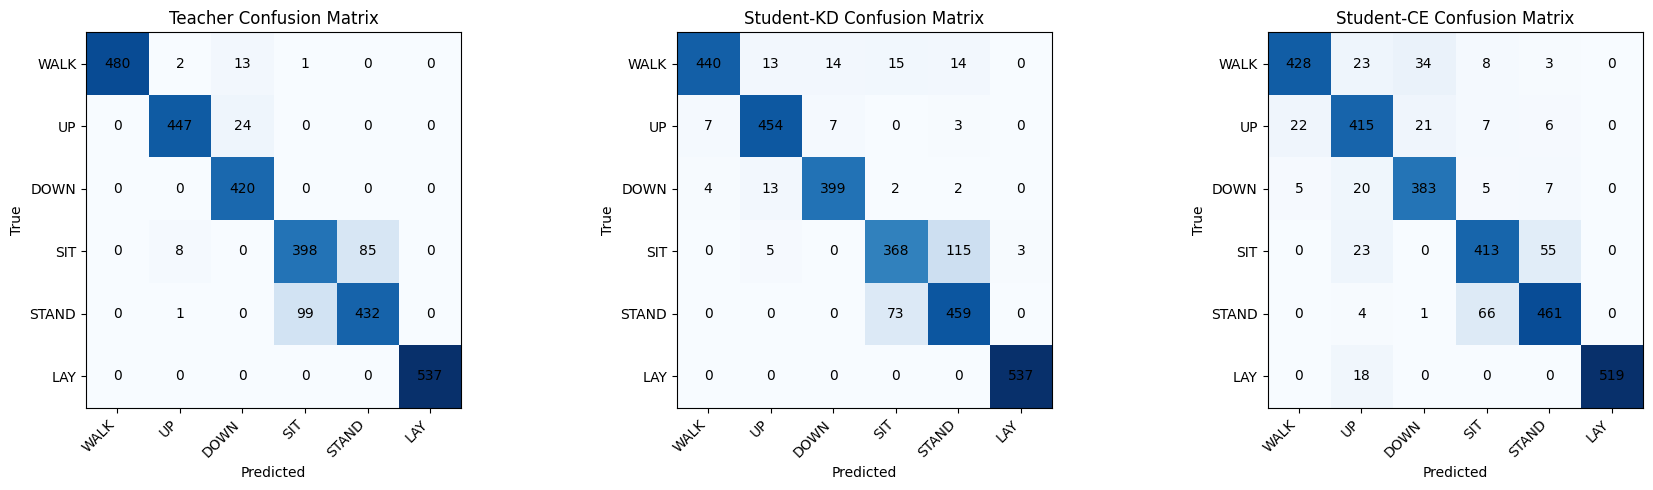

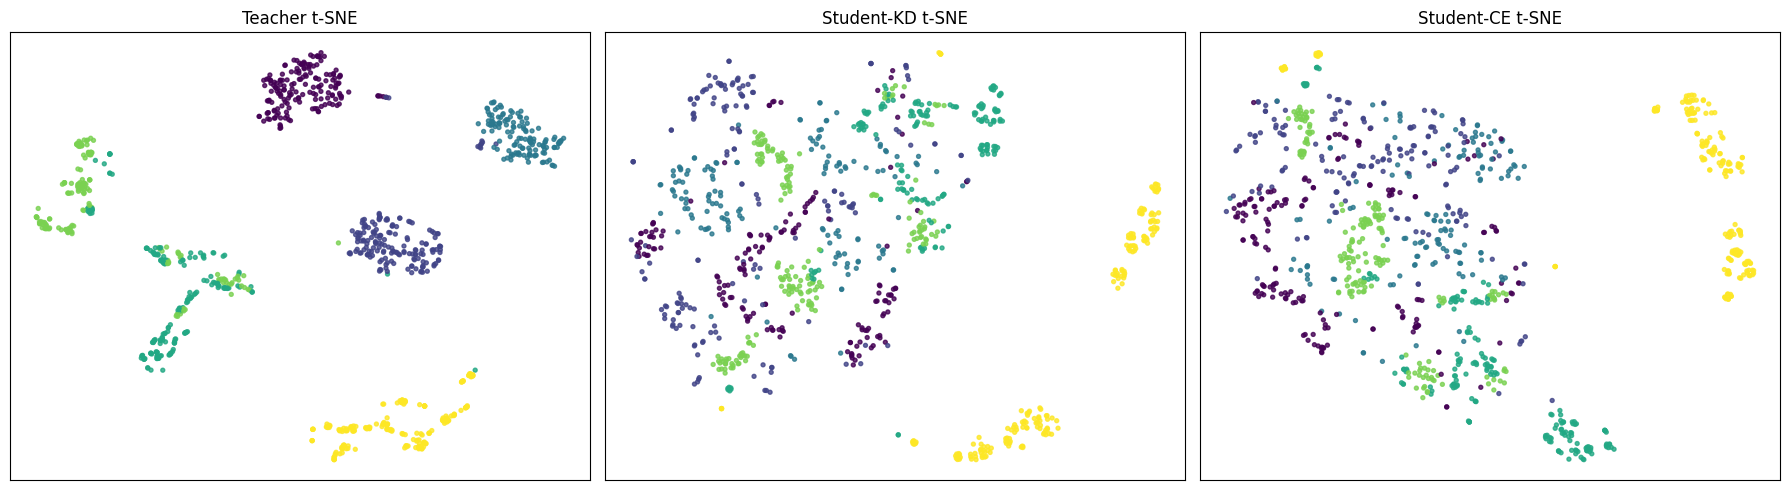

In [2]:
import os
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from fvcore.nn import FlopCountAnalysis


# ==============================================================================
# Config
# ==============================================================================
SEED = 42
DATA_DIR = "/content/drive/MyDrive/Colab Notebooks/datasets/UCI-HAR"
CLASS_NAMES = ["WALK", "UP", "DOWN", "SIT", "STAND", "LAY"]

BATCH_SIZE = 128
EPOCHS = 50
LR = 1e-3
WEIGHT_DECAY = 1e-4

# KD Config
TEMPERATURE = 4.0
ALPHA_CE = 0.3
ALPHA_KD = 0.7

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
set_seed(SEED)


# ==============================================================================
# Dataset
# ==============================================================================
class UCIHARDataset(Dataset):
    def __init__(self, data_dir, split="train"):
        self.data_dir = Path(data_dir)
        self.split    = split
        self.X, self.y = self._load_data()
        self.X = torch.FloatTensor(self.X)
        self.y = torch.LongTensor(self.y) - 1
    def _load_data(self):
        split_dir = self.data_dir / self.split
        signal_types = [
            "body_acc_x", "body_acc_y", "body_acc_z",
            "body_gyro_x", "body_gyro_y", "body_gyro_z",
            "total_acc_x", "total_acc_y", "total_acc_z",]
        signals = []
        for st in signal_types:
            fname = split_dir / "Inertial Signals" / f"{st}_{self.split}.txt"
            signals.append(np.loadtxt(fname))
        X = np.stack(signals, axis=1)
        y = np.loadtxt(split_dir / f"y_{self.split}.txt", dtype=int)
        return X, y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        X = self.X[idx]
        y = self.y[idx]
        return X, y


# ==============================================================================
# Models
# ==============================================================================
class TeacherCNNLSTM(nn.Module):
    def __init__(self, in_channels=9, num_classes=6, hidden_dim=64):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Conv1d(64, 128, kernel_size=7, padding=3),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )

        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        self.classifier = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x, return_features=False):
        x = self.cnn(x)
        x = x.transpose(1, 2)
        out, _ = self.lstm(x)
        feat = out[:, -1, :]
        logits = self.classifier(feat)

        if return_features:
            return logits, feat

        return logits


class StudentLinear(nn.Module):
    def __init__(self, seq_len=128, in_channels=9, num_classes=6):
        super().__init__()

        input_dim = seq_len * in_channels

        self.feature_extractor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, 64),
            nn.ReLU()
        )

        self.classifier = nn.Linear(64, num_classes)

    def forward(self, x, return_features=False):
        feat = self.feature_extractor(x)
        logits = self.classifier(feat)

        if return_features:
            return logits, feat

        return logits


# ==============================================================================
# Train Teacher
# ==============================================================================
def train_teacher(teacher, train_loader, test_loader, epochs=30):
    teacher = teacher.to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        teacher.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )

    for epoch in range(1, epochs + 1):
        teacher.train()

        total_loss = 0.0
        total_count = 0

        for X, y in train_loader:
            X = X.to(DEVICE)
            y = y.to(DEVICE)

            optimizer.zero_grad()

            teacher_logits = teacher(X)
            loss = criterion(teacher_logits, y)

            loss.backward()
            optimizer.step()

            total_loss += loss.item() * y.size(0)
            total_count += y.size(0)

        train_loss = total_loss / total_count
        test_acc, test_f1, _, _ = evaluate(teacher, test_loader)

        if epoch % 10 == 0 or epoch == 1 or epoch == epochs:
            print(
                f"[Teacher] Epoch [{epoch:03d}/{epochs}] | "
                f"Loss: {train_loss:.4f} | "
                f"Test Acc: {test_acc:.4f} | "
                f"Test Macro-F1: {test_f1:.4f}"
            )

    return teacher


# ==============================================================================
# Train Student with KD
# ==============================================================================
def distillation_loss(student_logits, teacher_logits, labels):
    ce_loss = F.cross_entropy(student_logits, labels)

    kd_loss = F.kl_div(
        F.log_softmax(student_logits / TEMPERATURE, dim=1),
        F.softmax(teacher_logits / TEMPERATURE, dim=1),
        reduction="batchmean"
    ) * (TEMPERATURE ** 2)

    total_loss = ALPHA_CE * ce_loss + ALPHA_KD * kd_loss

    return total_loss, ce_loss, kd_loss


def train_student_kd(student, teacher, train_loader, test_loader, epochs=30):
    student = student.to(DEVICE)
    teacher = teacher.to(DEVICE)

    teacher.eval()
    for p in teacher.parameters():
        p.requires_grad = False

    optimizer = torch.optim.AdamW(
        student.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )

    for epoch in range(1, epochs + 1):
        student.train()

        total_loss_sum = 0.0
        ce_loss_sum = 0.0
        kd_loss_sum = 0.0
        total_count = 0

        for X, y in train_loader:
            X = X.to(DEVICE)
            y = y.to(DEVICE)

            optimizer.zero_grad()

            with torch.no_grad():
                teacher_logits = teacher(X)

            student_logits = student(X)

            loss, ce_loss, kd_loss = distillation_loss(
                student_logits,
                teacher_logits,
                y
            )

            loss.backward()
            optimizer.step()

            batch_size = y.size(0)

            total_loss_sum += loss.item() * batch_size
            ce_loss_sum += ce_loss.item() * batch_size
            kd_loss_sum += kd_loss.item() * batch_size
            total_count += batch_size

        train_loss = total_loss_sum / total_count
        avg_ce_loss = ce_loss_sum / total_count
        avg_kd_loss = kd_loss_sum / total_count

        test_acc, test_f1, _, _ = evaluate(student, test_loader)

        if epoch % 10 == 0 or epoch == 1 or epoch == epochs:
            print(
                f"[Student-KD] Epoch [{epoch:03d}/{epochs}] | "
                f"Loss: {train_loss:.4f} | "
                f"CE: {avg_ce_loss:.4f} | "
                f"KD: {avg_kd_loss:.4f} | "
                f"Test Acc: {test_acc:.4f} | "
                f"Test Macro-F1: {test_f1:.4f}"
            )

    return student


# ==============================================================================
# Train Student with CE only
# ==============================================================================
def train_student_ce(student, train_loader, test_loader, epochs=30):
    student = student.to(DEVICE)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        student.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )

    for epoch in range(1, epochs + 1):
        student.train()

        total_loss = 0.0
        total_count = 0

        for X, y in train_loader:
            X = X.to(DEVICE)
            y = y.to(DEVICE)

            optimizer.zero_grad()

            logits = student(X)
            loss = criterion(logits, y)

            loss.backward()
            optimizer.step()

            total_loss += loss.item() * y.size(0)
            total_count += y.size(0)

        train_loss = total_loss / total_count
        test_acc, test_f1, _, _ = evaluate(student, test_loader)

        if epoch % 10 == 0 or epoch == 1 or epoch == epochs:
            print(
                f"[Student-CE] Epoch [{epoch:03d}/{epochs}] | "
                f"Loss: {train_loss:.4f} | "
                f"Test Acc: {test_acc:.4f} | "
                f"Test Macro-F1: {test_f1:.4f}"
            )

    return student


# ==============================================================================
# Eval
# ==============================================================================
@torch.no_grad()
def evaluate(model, loader):
    model.eval()

    all_preds = []
    all_labels = []

    for X, y in loader:
        X = X.to(DEVICE)
        y = y.to(DEVICE)

        logits = model(X)
        preds = torch.argmax(logits, dim=1)

        all_preds.append(preds.cpu().numpy())
        all_labels.append(y.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")

    return acc, macro_f1, all_labels, all_preds


# ==============================================================================
# Utils
# ==============================================================================
def count_params(model):
    return sum(p.numel() for p in model.parameters())
def compute_flops(model, input_shape=(1, 9, 128)):
    model = model.to(DEVICE)
    model.eval()
    dummy = torch.randn(*input_shape).to(DEVICE)
    try:
        flops = FlopCountAnalysis(model, dummy).total()
    except Exception as e:
        print(f"FLOPs calculation failed: {e}")
        flops = None
    return flops
def plot_three_confusion_matrices(results_dict):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, (name, result) in zip(axes, results_dict.items()):
        y_true = result["y_true"]
        y_pred = result["y_pred"]
        cm = confusion_matrix(y_true, y_pred)
        ax.imshow(cm, cmap="Blues")
        ax.set_title(f"{name} Confusion Matrix")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
        ax.set_xticks(np.arange(len(CLASS_NAMES)))
        ax.set_yticks(np.arange(len(CLASS_NAMES)))
        ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
        ax.set_yticklabels(CLASS_NAMES)
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    plt.tight_layout()
    plt.show()
@torch.no_grad()
def extract_features(model, loader):
    model.eval()
    all_feats = []
    all_labels = []
    for X, y in loader:
        X = X.to(DEVICE)
        logits, feats = model(X, return_features=True)
        all_feats.append(feats.cpu().numpy())
        all_labels.append(y.numpy())
    all_feats = np.concatenate(all_feats)
    all_labels = np.concatenate(all_labels)
    return all_feats, all_labels
def plot_three_tsne(models_dict, loader, max_samples=1000):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, (name, model) in zip(axes, models_dict.items()):
        feats, labels = extract_features(model, loader)
        if len(feats) > max_samples:
            idx = np.random.choice(len(feats), max_samples, replace=False)
            feats = feats[idx]
            labels = labels[idx]
        tsne = TSNE(
            n_components=2,
            perplexity=30,
            learning_rate="auto",
            init="pca",
            random_state=SEED)
        z = tsne.fit_transform(feats)
        scatter = ax.scatter(
            z[:, 0],
            z[:, 1],
            c=labels,
            s=8,
            alpha=0.8)
        ax.set_title(f"{name} t-SNE")
        ax.set_xticks([])
        ax.set_yticks([])
    plt.tight_layout()
    plt.show()


# ==============================================================================
# Main
# ==============================================================================
if __name__ == "__main__":

    # --------------------------------------------------------------------------
    # 1. DataLoader
    # --------------------------------------------------------------------------
    train_dataset = UCIHARDataset(DATA_DIR, split="train")
    test_dataset  = UCIHARDataset(DATA_DIR, split="test")

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    # --------------------------------------------------------------------------
    # 2. Model 생성
    # --------------------------------------------------------------------------
    teacher = TeacherCNNLSTM(
        in_channels=9,
        num_classes=6,
        hidden_dim=64
    )

    student_kd = StudentLinear(
        seq_len=128,
        in_channels=9,
        num_classes=6
    )

    student_ce = StudentLinear(
        seq_len=128,
        in_channels=9,
        num_classes=6
    )

    # --------------------------------------------------------------------------
    # 3. Train Teacher
    # --------------------------------------------------------------------------
    print("\n" + "=" * 80)
    print("Train Teacher")
    print("=" * 80)

    teacher = train_teacher(
        teacher,
        train_loader,
        test_loader,
        epochs=EPOCHS
    )

    teacher_acc, teacher_f1, teacher_y_true, teacher_y_pred = evaluate(
        teacher,
        test_loader
    )

    print("\n[Teacher Final]")
    print(f"Test Acc      : {teacher_acc:.4f}")
    print(f"Test Macro-F1 : {teacher_f1:.4f}")

    # --------------------------------------------------------------------------
    # 4. Train Student with KD
    # --------------------------------------------------------------------------
    print("\n" + "=" * 80)
    print("Train Student with KD")
    print("=" * 80)

    student_kd = train_student_kd(
        student_kd,
        teacher,
        train_loader,
        test_loader,
        epochs=EPOCHS
    )

    student_kd_acc, student_kd_f1, student_kd_y_true, student_kd_y_pred = evaluate(
        student_kd,
        test_loader
    )

    print("\n[Student-KD Final]")
    print(f"Test Acc      : {student_kd_acc:.4f}")
    print(f"Test Macro-F1 : {student_kd_f1:.4f}")

    # --------------------------------------------------------------------------
    # 5. Train Student with CE only
    # --------------------------------------------------------------------------
    print("\n" + "=" * 80)
    print("Train Student with CE only")
    print("=" * 80)

    student_ce = train_student_ce(
        student_ce,
        train_loader,
        test_loader,
        epochs=EPOCHS
    )

    student_ce_acc, student_ce_f1, student_ce_y_true, student_ce_y_pred = evaluate(
        student_ce,
        test_loader
    )

    print("\n[Student-CE Final]")
    print(f"Test Acc      : {student_ce_acc:.4f}")
    print(f"Test Macro-F1 : {student_ce_f1:.4f}")

    # --------------------------------------------------------------------------
    # 6. Summary Table: F1, Params, FLOPs
    # --------------------------------------------------------------------------
    teacher_params = count_params(teacher)
    student_kd_params = count_params(student_kd)
    student_ce_params = count_params(student_ce)

    teacher_flops = compute_flops(teacher)
    student_kd_flops = compute_flops(student_kd)
    student_ce_flops = compute_flops(student_ce)

    summary_df = pd.DataFrame({
        "Model": [
            "Teacher",
            "Student-KD",
            "Student-CE"
        ],
        "Test Macro-F1": [
            teacher_f1,
            student_kd_f1,
            student_ce_f1
        ],
        "Params": [
            teacher_params,
            student_kd_params,
            student_ce_params
        ],
        "FLOPs": [
            teacher_flops,
            student_kd_flops,
            student_ce_flops
        ]
    })

    print("\n" + "=" * 80)
    print("Summary Table")
    print("=" * 80)
    print(summary_df)

    # --------------------------------------------------------------------------
    # 7. Plot[1]: Confusion Matrix
    # --------------------------------------------------------------------------
    results_dict = {
        "Teacher": {
            "y_true": teacher_y_true,
            "y_pred": teacher_y_pred
        },
        "Student-KD": {
            "y_true": student_kd_y_true,
            "y_pred": student_kd_y_pred
        },
        "Student-CE": {
            "y_true": student_ce_y_true,
            "y_pred": student_ce_y_pred
        }
    }

    plot_three_confusion_matrices(results_dict)

    # --------------------------------------------------------------------------
    # 8. Plot[2]: t-SNE
    # --------------------------------------------------------------------------
    models_dict = {
        "Teacher": teacher,
        "Student-KD": student_kd,
        "Student-CE": student_ce
    }

    plot_three_tsne(
        models_dict,
        test_loader,
        max_samples=1000
    )

Device: cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Resolved DATA_ROOT: /content/drive/MyDrive/Colab Notebooks/datasets/UCI-HAR
X_train_all: (7352, 128, 9)
y_train_all: (7352,)
X_test: (2947, 128, 9)
y_test: (2947,)
Activity names: ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']

Train shape: (5879, 128, 9)
Val shape: (1473, 128, 9)
Test shape: (2947, 128, 9)
Train subjects: [5, 6, 7, 8, 11, 14, 15, 16, 17, 19, 21, 22, 23, 26, 28, 29, 30]
Val subjects: [1, 3, 25, 27]
Test subjects: [2, 4, 9, 10, 12, 13, 18, 20, 24]

Teacher parameters: 870087
Student parameters: 12198
Compression ratio: 71.3303000491884
[Teacher] Epoch 001/80 | Train Loss 0.2995 | Val Loss 0.1495 | Val Acc 0.9511 | Val Macro-F1 0.9504 | 7.5s
[Teacher] Epoch 002/80 | Train Loss 0.1594 | Val Loss 0.1234 | Val Acc 0.9681 | Val Macro-F1 0.9680 | 1.1s
[Teacher] Epoch 003/80 | Train Loss 0.1360 | V

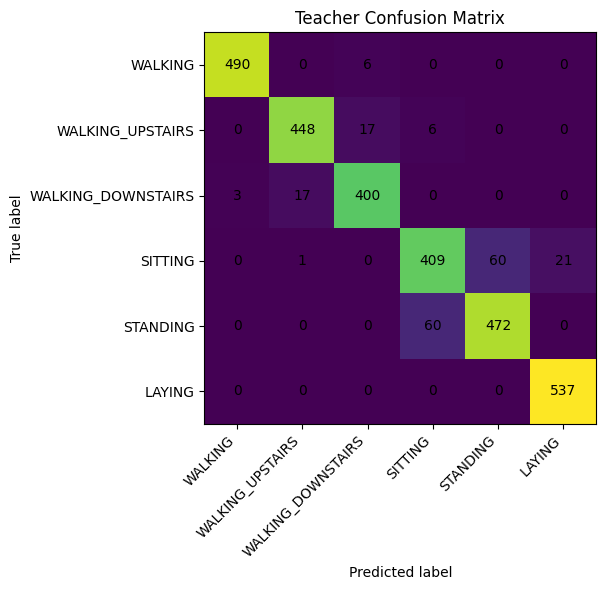

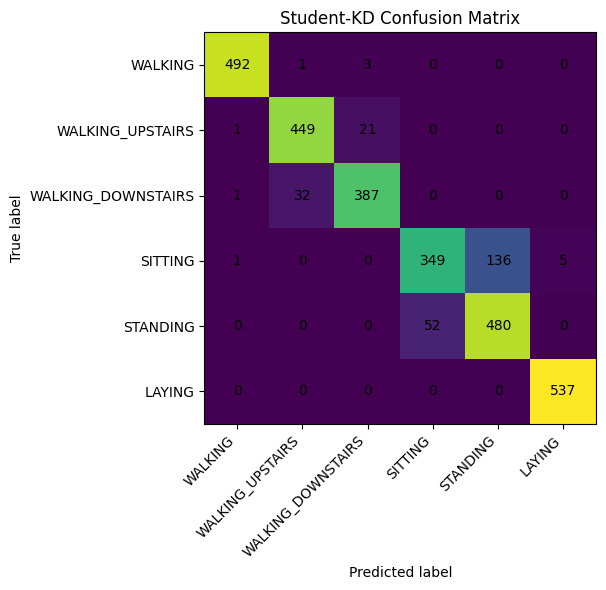

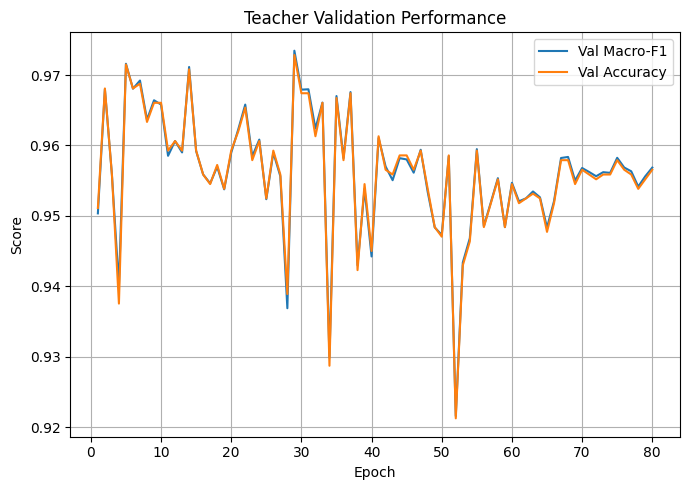

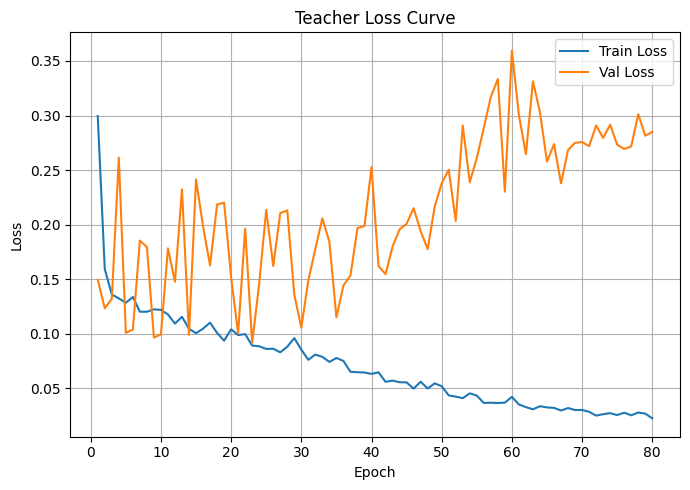

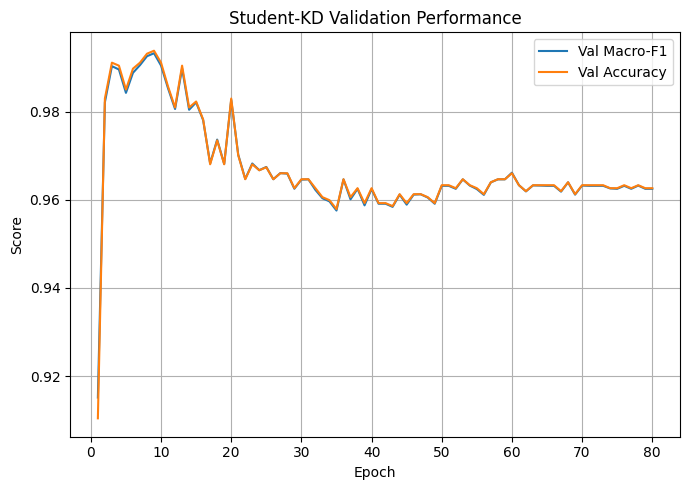

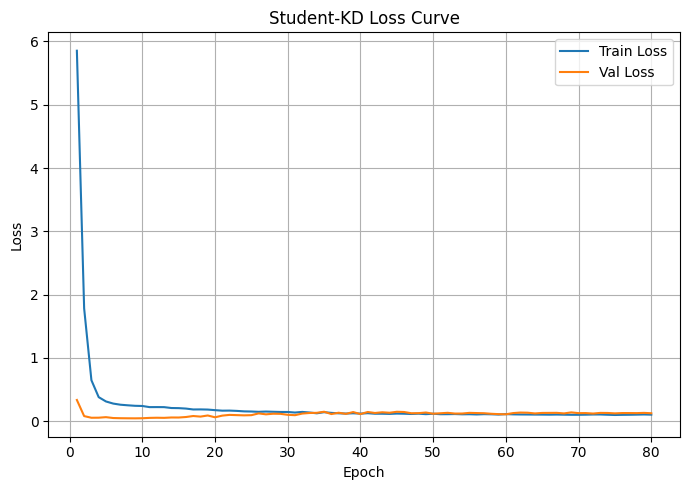

In [3]:
import os
import random
import copy
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader


# ============================================================
# 1. Basic Settings
# ============================================================

SEED = 42
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/datasets/UCI-HAR"

BATCH_SIZE = 128
TEACHER_EPOCHS = 80
STUDENT_EPOCHS = 80

LR_TEACHER = 1e-3
LR_STUDENT = 1e-3
WEIGHT_DECAY = 1e-4

TEMPERATURE = 4.0
ALPHA_CE = 0.3
ALPHA_KD = 0.7

VAL_SUBJECT_RATIO = 0.15
NUM_CLASSES = 6

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


set_seed(SEED)

print("Device:", DEVICE)


# ============================================================
# 2. Google Drive Mount
# ============================================================

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception as e:
    print("Google Drive mount skipped:", e)


# ============================================================
# 3. Resolve UCI-HAR Root
# ============================================================

def resolve_uci_har_root(base_dir):
    candidates = [
        base_dir,
        os.path.join(base_dir, "UCI HAR Dataset"),
        os.path.join(base_dir, "UCI-HAR"),
        os.path.join(base_dir, "UCI_HAR_Dataset"),
    ]

    for path in candidates:
        train_signal_dir = os.path.join(path, "train", "Inertial Signals")
        test_signal_dir = os.path.join(path, "test", "Inertial Signals")

        if os.path.isdir(train_signal_dir) and os.path.isdir(test_signal_dir):
            return path

    raise FileNotFoundError(
        "UCI-HAR root directory was not found. "
        "Please check BASE_DIR and make sure train/test/Inertial Signals folders exist."
    )


DATA_ROOT = resolve_uci_har_root(BASE_DIR)
print("Resolved DATA_ROOT:", DATA_ROOT)


# ============================================================
# 4. Load UCI-HAR Raw Inertial Signals
# ============================================================

SIGNAL_NAMES = [
    "body_acc_x",
    "body_acc_y",
    "body_acc_z",
    "body_gyro_x",
    "body_gyro_y",
    "body_gyro_z",
    "total_acc_x",
    "total_acc_y",
    "total_acc_z",
]

DEFAULT_ACTIVITY_NAMES = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING",
]


def load_split(root_dir, split):
    signal_dir = os.path.join(root_dir, split, "Inertial Signals")

    signals = []
    for sig in SIGNAL_NAMES:
        file_path = os.path.join(signal_dir, f"{sig}_{split}.txt")
        arr = np.loadtxt(file_path, dtype=np.float32)
        signals.append(arr)

    X = np.stack(signals, axis=-1).astype(np.float32)

    y_path = os.path.join(root_dir, split, f"y_{split}.txt")
    y = np.loadtxt(y_path, dtype=np.int64) - 1

    subject_path = os.path.join(root_dir, split, f"subject_{split}.txt")
    subjects = np.loadtxt(subject_path, dtype=np.int64)

    return X, y, subjects


def load_activity_names(root_dir):
    label_path = os.path.join(root_dir, "activity_labels.txt")

    if not os.path.exists(label_path):
        return DEFAULT_ACTIVITY_NAMES

    df = pd.read_csv(label_path, sep=r"\s+", header=None, names=["id", "name"])
    return df["name"].tolist()


X_train_all, y_train_all, subj_train_all = load_split(DATA_ROOT, "train")
X_test, y_test, subj_test = load_split(DATA_ROOT, "test")
activity_names = load_activity_names(DATA_ROOT)

print("X_train_all:", X_train_all.shape)
print("y_train_all:", y_train_all.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
print("Activity names:", activity_names)


# ============================================================
# 5. Subject-Disjoint Validation Split
# ============================================================

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=VAL_SUBJECT_RATIO,
    random_state=SEED
)

train_idx, val_idx = next(
    gss.split(X_train_all, y_train_all, groups=subj_train_all)
)

X_train = X_train_all[train_idx]
y_train = y_train_all[train_idx]
subj_train = subj_train_all[train_idx]

X_val = X_train_all[val_idx]
y_val = y_train_all[val_idx]
subj_val = subj_train_all[val_idx]

print("\nTrain shape:", X_train.shape)
print("Val shape:", X_val.shape)
print("Test shape:", X_test.shape)

print("Train subjects:", sorted(np.unique(subj_train).tolist()))
print("Val subjects:", sorted(np.unique(subj_val).tolist()))
print("Test subjects:", sorted(np.unique(subj_test).tolist()))


# ============================================================
# 6. Train-only Normalization
# ============================================================

def fit_normalizer(X):
    mean = X.mean(axis=(0, 1), keepdims=True)
    std = X.std(axis=(0, 1), keepdims=True)
    std = np.where(std < 1e-8, 1.0, std)
    return mean.astype(np.float32), std.astype(np.float32)


def apply_normalizer(X, mean, std):
    return ((X - mean) / std).astype(np.float32)


mean, std = fit_normalizer(X_train)

X_train = apply_normalizer(X_train, mean, std)
X_val = apply_normalizer(X_val, mean, std)
X_test = apply_normalizer(X_test, mean, std)


# ============================================================
# 7. Dataset and DataLoader
# ============================================================

class UCIHARDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_loader = DataLoader(
    UCIHARDataset(X_train, y_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    UCIHARDataset(X_val, y_val),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    UCIHARDataset(X_test, y_test),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


# ============================================================
# 8. Model Definition
# ============================================================

class ConvBNAct(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=5, dropout=0.1):
        super().__init__()
        padding = kernel_size // 2

        self.net = nn.Sequential(
            nn.Conv1d(
                in_channels,
                out_channels,
                kernel_size=kernel_size,
                padding=padding,
                bias=False
            ),
            nn.BatchNorm1d(out_channels),
            nn.SiLU(),
            nn.Dropout(dropout),

            nn.Conv1d(
                out_channels,
                out_channels,
                kernel_size=kernel_size,
                padding=padding,
                bias=False
            ),
            nn.BatchNorm1d(out_channels),
            nn.SiLU()
        )

        self.shortcut = nn.Identity()
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_channels)
            )

    def forward(self, x):
        return self.net(x) + self.shortcut(x)


class TemporalAttentionPooling(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.score = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.Tanh(),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, x):
        scores = self.score(x)
        weights = torch.softmax(scores, dim=1)
        pooled = torch.sum(weights * x, dim=1)
        return pooled


class TeacherHARNet(nn.Module):
    def __init__(self, in_channels=9, num_classes=6):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=7, padding=3, bias=False),
            nn.BatchNorm1d(64),
            nn.SiLU()
        )

        self.block1 = ConvBNAct(64, 64, kernel_size=5, dropout=0.10)
        self.pool1 = nn.MaxPool1d(kernel_size=2)

        self.block2 = ConvBNAct(64, 128, kernel_size=5, dropout=0.15)
        self.pool2 = nn.MaxPool1d(kernel_size=2)

        self.block3 = ConvBNAct(128, 256, kernel_size=3, dropout=0.20)

        self.bigru = nn.GRU(
            input_size=256,
            hidden_size=128,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )

        self.att_pool = TemporalAttentionPooling(hidden_dim=256)

        self.classifier = nn.Sequential(
            nn.LayerNorm(256),
            nn.Linear(256, 128),
            nn.SiLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = x.transpose(1, 2)

        x = self.stem(x)
        x = self.block1(x)
        x = self.pool1(x)

        x = self.block2(x)
        x = self.pool2(x)

        x = self.block3(x)

        x = x.transpose(1, 2)
        x, _ = self.bigru(x)

        x = self.att_pool(x)
        logits = self.classifier(x)

        return logits


class DepthwiseSeparableConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=5, dropout=0.1):
        super().__init__()
        padding = kernel_size // 2

        self.depthwise = nn.Conv1d(
            in_channels,
            in_channels,
            kernel_size=kernel_size,
            padding=padding,
            groups=in_channels,
            bias=False
        )

        self.pointwise = nn.Conv1d(
            in_channels,
            out_channels,
            kernel_size=1,
            bias=False
        )

        self.bn = nn.BatchNorm1d(out_channels)
        self.act = nn.SiLU()
        self.dropout = nn.Dropout(dropout)

        self.shortcut = nn.Identity()
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_channels)
            )

    def forward(self, x):
        out = self.depthwise(x)
        out = self.pointwise(out)
        out = self.bn(out)
        out = self.act(out)
        out = self.dropout(out)

        return out + self.shortcut(x)


class StudentHARNet(nn.Module):
    def __init__(self, in_channels=9, num_classes=6):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=5, padding=2, bias=False),
            nn.BatchNorm1d(32),
            nn.SiLU(),

            DepthwiseSeparableConv1d(32, 32, kernel_size=5, dropout=0.10),
            nn.MaxPool1d(kernel_size=2),

            DepthwiseSeparableConv1d(32, 64, kernel_size=5, dropout=0.15),
            nn.MaxPool1d(kernel_size=2),

            DepthwiseSeparableConv1d(64, 64, kernel_size=3, dropout=0.15),
            nn.AdaptiveAvgPool1d(1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.LayerNorm(64),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.net(x)
        logits = self.classifier(x)
        return logits


# ============================================================
# 9. Utility Functions
# ============================================================

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


@torch.no_grad()
def evaluate(model, loader, criterion=None):
    model.eval()

    total_loss = 0.0
    total_count = 0

    all_preds = []
    all_labels = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        logits = model(X_batch)

        if criterion is not None:
            loss = criterion(logits, y_batch)
            total_loss += loss.item() * y_batch.size(0)

        preds = torch.argmax(logits, dim=1)

        all_preds.append(preds.cpu().numpy())
        all_labels.append(y_batch.cpu().numpy())

        total_count += y_batch.size(0)

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    weighted_f1 = f1_score(all_labels, all_preds, average="weighted")

    avg_loss = total_loss / total_count if criterion is not None else None

    return {
        "loss": avg_loss,
        "acc": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "y_true": all_labels,
        "y_pred": all_preds
    }


def train_teacher(model, train_loader, val_loader):
    model = model.to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR_TEACHER,
        weight_decay=WEIGHT_DECAY
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=TEACHER_EPOCHS
    )

    best_state = copy.deepcopy(model.state_dict())
    best_val_f1 = -1.0

    history = []

    for epoch in range(1, TEACHER_EPOCHS + 1):
        model.train()
        start_time = time.time()

        train_loss_sum = 0.0
        train_count = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            optimizer.zero_grad()

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            train_loss_sum += loss.item() * y_batch.size(0)
            train_count += y_batch.size(0)

        scheduler.step()

        train_loss = train_loss_sum / train_count
        val_result = evaluate(model, val_loader, criterion)

        if val_result["macro_f1"] > best_val_f1:
            best_val_f1 = val_result["macro_f1"]
            best_state = copy.deepcopy(model.state_dict())

        elapsed = time.time() - start_time

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_result["loss"],
            "val_acc": val_result["acc"],
            "val_macro_f1": val_result["macro_f1"],
            "time_sec": elapsed
        }

        history.append(row)

        print(
            f"[Teacher] Epoch {epoch:03d}/{TEACHER_EPOCHS} | "
            f"Train Loss {train_loss:.4f} | "
            f"Val Loss {val_result['loss']:.4f} | "
            f"Val Acc {val_result['acc']:.4f} | "
            f"Val Macro-F1 {val_result['macro_f1']:.4f} | "
            f"{elapsed:.1f}s"
        )

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)


def distillation_loss(student_logits, teacher_logits, labels):
    ce_loss = F.cross_entropy(student_logits, labels)

    kd_loss = F.kl_div(
        F.log_softmax(student_logits / TEMPERATURE, dim=1),
        F.softmax(teacher_logits / TEMPERATURE, dim=1),
        reduction="batchmean"
    ) * (TEMPERATURE ** 2)

    total_loss = ALPHA_CE * ce_loss + ALPHA_KD * kd_loss

    return total_loss, ce_loss.detach(), kd_loss.detach()


def train_student_with_kd(student, teacher, train_loader, val_loader):
    student = student.to(DEVICE)
    teacher = teacher.to(DEVICE)
    teacher.eval()

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        student.parameters(),
        lr=LR_STUDENT,
        weight_decay=WEIGHT_DECAY
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=STUDENT_EPOCHS
    )

    best_state = copy.deepcopy(student.state_dict())
    best_val_f1 = -1.0

    history = []

    for epoch in range(1, STUDENT_EPOCHS + 1):
        student.train()
        start_time = time.time()

        train_loss_sum = 0.0
        ce_loss_sum = 0.0
        kd_loss_sum = 0.0
        train_count = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            optimizer.zero_grad()

            with torch.no_grad():
                teacher_logits = teacher(X_batch)

            student_logits = student(X_batch)

            loss, ce_loss, kd_loss = distillation_loss(
                student_logits,
                teacher_logits,
                y_batch
            )

            loss.backward()
            torch.nn.utils.clip_grad_norm_(student.parameters(), max_norm=5.0)
            optimizer.step()

            batch_size = y_batch.size(0)

            train_loss_sum += loss.item() * batch_size
            ce_loss_sum += ce_loss.item() * batch_size
            kd_loss_sum += kd_loss.item() * batch_size
            train_count += batch_size

        scheduler.step()

        train_loss = train_loss_sum / train_count
        avg_ce_loss = ce_loss_sum / train_count
        avg_kd_loss = kd_loss_sum / train_count

        val_result = evaluate(student, val_loader, criterion)

        if val_result["macro_f1"] > best_val_f1:
            best_val_f1 = val_result["macro_f1"]
            best_state = copy.deepcopy(student.state_dict())

        elapsed = time.time() - start_time

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "ce_loss": avg_ce_loss,
            "kd_loss": avg_kd_loss,
            "val_loss": val_result["loss"],
            "val_acc": val_result["acc"],
            "val_macro_f1": val_result["macro_f1"],
            "time_sec": elapsed
        }

        history.append(row)

        print(
            f"[Student-KD] Epoch {epoch:03d}/{STUDENT_EPOCHS} | "
            f"Loss {train_loss:.4f} | "
            f"CE {avg_ce_loss:.4f} | "
            f"KD {avg_kd_loss:.4f} | "
            f"Val Acc {val_result['acc']:.4f} | "
            f"Val Macro-F1 {val_result['macro_f1']:.4f} | "
            f"{elapsed:.1f}s"
        )

    student.load_state_dict(best_state)
    return student, pd.DataFrame(history)


# ============================================================
# 10. Train Teacher
# ============================================================

teacher = TeacherHARNet(
    in_channels=len(SIGNAL_NAMES),
    num_classes=NUM_CLASSES
)

student = StudentHARNet(
    in_channels=len(SIGNAL_NAMES),
    num_classes=NUM_CLASSES
)

print("\nTeacher parameters:", count_parameters(teacher))
print("Student parameters:", count_parameters(student))
print("Compression ratio:", count_parameters(teacher) / count_parameters(student))

teacher, teacher_history = train_teacher(
    teacher,
    train_loader,
    val_loader
)


# ============================================================
# 11. Train Student with Knowledge Distillation
# ============================================================

student, student_history = train_student_with_kd(
    student,
    teacher,
    train_loader,
    val_loader
)


# ============================================================
# 12. Final Test Evaluation
# ============================================================

criterion = nn.CrossEntropyLoss()

teacher_test = evaluate(teacher, test_loader, criterion)
student_test = evaluate(student, test_loader, criterion)

print("\n================ Final Test Results ================")

print(
    f"Teacher | "
    f"Acc: {teacher_test['acc']:.4f} | "
    f"Macro-F1: {teacher_test['macro_f1']:.4f} | "
    f"Weighted-F1: {teacher_test['weighted_f1']:.4f}"
)

print(
    f"Student-KD | "
    f"Acc: {student_test['acc']:.4f} | "
    f"Macro-F1: {student_test['macro_f1']:.4f} | "
    f"Weighted-F1: {student_test['weighted_f1']:.4f}"
)

print("\nTeacher Classification Report")
print(
    classification_report(
        teacher_test["y_true"],
        teacher_test["y_pred"],
        target_names=activity_names,
        digits=4
    )
)

print("\nStudent-KD Classification Report")
print(
    classification_report(
        student_test["y_true"],
        student_test["y_pred"],
        target_names=activity_names,
        digits=4
    )
)


# ============================================================
# 13. Confusion Matrix
# ============================================================

def plot_confusion_matrix(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.xticks(np.arange(len(class_names)), class_names, rotation=45, ha="right")
    plt.yticks(np.arange(len(class_names)), class_names)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.show()


plot_confusion_matrix(
    teacher_test["y_true"],
    teacher_test["y_pred"],
    activity_names,
    "Teacher Confusion Matrix"
)

plot_confusion_matrix(
    student_test["y_true"],
    student_test["y_pred"],
    activity_names,
    "Student-KD Confusion Matrix"
)


# ============================================================
# 14. Training Curves
# ============================================================

def plot_history(history_df, title_prefix):
    plt.figure(figsize=(7, 5))
    plt.plot(history_df["epoch"], history_df["val_macro_f1"], label="Val Macro-F1")
    plt.plot(history_df["epoch"], history_df["val_acc"], label="Val Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.title(f"{title_prefix} Validation Performance")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
    plt.plot(history_df["epoch"], history_df["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix} Loss Curve")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


plot_history(teacher_history, "Teacher")
plot_history(student_history, "Student-KD")